# Emotion Detection with Deep Learning: RNN vs LSTM vs GRU vs Bidirectional GRU

## 1. Project Overview

### Problem Statement

Humans express emotion through language all the time — in tweets, reviews, chat
messages, journal entries. A machine reading a sentence like *"I can't believe how
happy I am right now!"* has no built-in sense of what "happy" means, let alone that
the whole sentence expresses **joy**. This notebook builds a system that reads a
short piece of English text and predicts which of six emotions it expresses:

`sadness`, `joy`, `love`, `anger`, `fear`, `surprise`

This is a **text classification** problem — specifically **emotion detection**, a
close cousin of sentiment analysis (which usually only asks positive vs. negative).
Here we ask a finer-grained question: *which specific emotion?*

### Objective

Train and compare several deep learning architectures that are commonly used for
text — a **Simple RNN**, an **LSTM**, a **GRU**, and a **Bidirectional GRU** — on the
same dataset, using the same preprocessing, so the comparison is fair. Then take the
best-performing model, test it on new sentences, and save it so it could be reused
later (for example, inside a small web app) without retraining.

### What We Are Building

By the end of this notebook we will have:

1. A cleaned, tokenized, padded version of the emotion dataset ready for a neural
   network.
2. Four trained models (RNN, LSTM, GRU, Bidirectional GRU) evaluated on the same
   test data.
3. A saved model file and a saved tokenizer, ready for future predictions on new
   sentences.

### End-to-End Pipeline

```text
Raw text + emotion label
        ↓
Load dataset (Hugging Face "dair-ai/emotion")
        ↓
Explore & understand the data (class balance, missing values)
        ↓
Convert text → integer tokens (Tokenizer)
        ↓
Make every sequence the same length (Padding)
        ↓
Feed sequences into neural networks (RNN → LSTM → GRU → Bidirectional GRU)
        ↓
Train each model and evaluate accuracy / loss
        ↓
Compare all four models
        ↓
Use the best model to predict emotions on brand-new sentences
        ↓
Save the trained model and the tokenizer for future use
```

> **Note on how this notebook is documented:** the Markdown cells you'll see
> throughout are explanations added on top of the original code — they describe
> *what the code does, why it was written this way, and what the actual outputs
> mean*. No code, model architecture, or hyperparameter has been changed. Where the
> notebook has a limitation or a questionable choice, it's called out explicitly
> rather than silently fixed — you'll see these flagged as **"Potential issue"** or
> **"Possible improvement."**


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt

### Tools We're Starting With

- **numpy** – for numerical arrays (the language neural networks "think" in).
- **pandas** – for organizing our text and labels into a table (DataFrame) we can
  inspect easily.
- **seaborn** / **matplotlib** – for plotting, so we can *see* things like class
  balance and confusion matrices instead of just reading numbers.

This is a normal first step in almost any data science notebook: bring in the
general-purpose tools before touching the actual dataset.


## 2. Understanding the Dataset

### Dataset Overview

We use the **`dair-ai/emotion`** dataset, hosted on the Hugging Face Hub. It's a
collection of short English sentences (mostly Twitter-style messages), each labeled
with one of six emotions. Hugging Face's `datasets` library lets us download and
load it with a single function call — no manual file handling required.

### Input and Target

| Component | Meaning |
|---|---|
| Input (feature) | The raw sentence, e.g. *"i feel so alone and hopeless today"* |
| Target (label) | One emotion class: sadness, joy, love, anger, fear, or surprise |
| Task Type | Multi-class text classification (6 classes) |


In [2]:
from datasets import load_dataset

d:\Study\data science portfolio projects\Emotion Predictor\backend\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
data_url = "https://huggingface.co/datasets/dair-ai/emotion"

The `data_url` variable above just documents where the dataset
comes from — it isn't used to actually download anything (that happens through the
`datasets` library, not a direct URL request). Think of it as a citation/reference.


In [4]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

This line silences a harmless warning Hugging Face sometimes
prints on Windows about symlinks. It doesn't affect the data or the model in any
way — it's just cleaning up the notebook's output.


### Loading the Data

**What are we about to do?** Download the `dair-ai/emotion` dataset directly from
the Hugging Face Hub.

**Why?** Rather than manually downloading a CSV and cleaning it ourselves, Hugging
Face's `load_dataset` function fetches an already-cleaned, pre-split dataset (train
/ validation / test) with one line of code.

**What should we expect?** A `DatasetDict` object — a dictionary-like container
holding three separate datasets: `train`, `validation`, and `test`.


In [5]:
emotion_dataset = load_dataset("dair-ai/emotion")

In [6]:
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

### What Happened?

The dataset loaded successfully. Looking at the printed structure:

| Split | Rows | Purpose |
|---|---|---|
| `train` | 16,000 | Used to teach the model |
| `validation` | 2,000 | *Intended* to be used to check performance during training, without ever training on it |
| `test` | 2,000 | Used for a final, untouched check of performance |

**What should I notice?** Every split has the same two columns: `text` and `label`.
The `label` column is stored as an **integer** (e.g. `0`, `1`, `2`...), not as the
word "joy" or "sadness" — we'll map those integers to readable names shortly.

> **Potential issue to watch for:** the dataset ships with a dedicated
> `validation` split specifically so that `test` can be held back untouched until
> the very end. Keep this in mind as we move through the notebook — we'll flag it
> again later when we see how `validation_data` is actually used during training.


### Extracting Text and Labels

Each split behaves like a dictionary of columns. Here we pull the `text` and
`label` columns out of the `train` and `test` splits into plain Python lists, which
will be easier to work with when we build a `pandas` DataFrame in a moment.

Notice that only `train` and `test` are extracted here — the `validation` split
loaded above is not pulled out at this stage.


In [7]:
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset["train"]["label"]

In [8]:
test_text = emotion_dataset["test"]["text"]
test_label = emotion_dataset["test"]["label"]

A quick sanity check — confirming the test set has the row
count we expect (2,000, matching what we saw in the dataset structure above).


In [9]:
len(test_label)

2000

### From Numbers Back to Words

The dataset stores labels as integers (0–5) for efficiency, but a `Dataset`
object in Hugging Face also keeps a record of what each integer *means*. Here we
retrieve that mapping so we can display human-readable emotion names instead of
raw numbers.


In [10]:
label_name = emotion_dataset["train"].features["label"].names
label_name

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

**Result:** the six possible emotions, in the order their
integer IDs correspond to:

`0 = sadness`, `1 = joy`, `2 = love`, `3 = anger`, `4 = fear`, `5 = surprise`

Keep this mapping in mind — it's the key we'll use throughout the notebook to turn
model outputs (numbers) back into meaningful emotion labels.


This loop just previews the label sequence in plain words
(rather than as integers) by mapping every training label through `label_name`. It's
a way to eyeball the data before building anything more structured. This cell is
mainly exploratory — the actual DataFrame we build next is what we'll use going
forward.


In [11]:
for i in train_label:
    print(label_name[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

### Building a DataFrame

Now we organize the text and (human-readable) labels into a `pandas` DataFrame —
essentially a spreadsheet-like table. This makes it much easier to inspect, filter,
and visualize the data than working with raw Python lists.


In [12]:
df_train = pd.DataFrame(
    {"text": train_text, "label": [label_name[i] for i in train_label]}
)

In [13]:
df_train.head()

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


**What should I notice?** Each row pairs a raw sentence with
its emotion label as plain text (not a number). This is the human-readable view of
the data we'll be preparing for the model.


The same transformation is repeated for the test set, so we
end up with two comparable DataFrames: `df_train` and `df_test`.


In [14]:
df_test = pd.DataFrame(
    {"text": test_text, "label": [label_name[i] for i in test_label]}
)

In [15]:
df_test.head()

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness


### Data Cleaning Check: Missing Values

**Why do this?** Before doing anything else, it's good practice to check for
missing (`null`) values. A missing sentence or missing label could cause errors
later or quietly corrupt training.

**What should I expect?** Ideally, zero missing values in both `text` and `label`
columns, for both `df_train` and `df_test`.


In [16]:
df_test.isnull().sum(), df_train.isnull().sum()

(text     0
 label    0
 dtype: int64,
 text     0
 label    0
 dtype: int64)

**Result:** both DataFrames show `0` missing values in every
column. This dataset is already clean — we can move on without needing to drop or
impute any rows.


### Class Distribution

**What are we about to do?** Count how many training examples exist for each
emotion.

**Why does this matter?** Neural networks learn from examples. If one class (say,
`joy`) has thousands of examples and another (say, `surprise`) has only a few
hundred, the model can become biased — it may learn to predict the majority class
more often simply because it "sees" it more, not because it's actually better at
recognizing it. This is called **class imbalance**, and it's one of the most common
practical issues in classification problems.


In [17]:
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

### Result Interpretation

| Emotion | Training Examples |
|---|---|
| joy | 5,362 |
| sadness | 4,666 |
| anger | 2,159 |
| fear | 1,937 |
| love | 1,304 |
| surprise | 572 |

This confirms real class imbalance: `joy` has roughly **9.4× more examples** than
`surprise`. Without correcting for this, a model could get deceptively "good"
accuracy just by leaning toward `joy` and `sadness` while rarely predicting
`surprise` or `love` correctly. We'll see this addressed later using **class
weights**.


A bar chart makes the imbalance from the table above much
easier to see at a glance — the height difference between `joy` and `surprise`
bars visually communicates the imbalance far more immediately than the raw
numbers.


<Axes: xlabel='label', ylabel='count'>

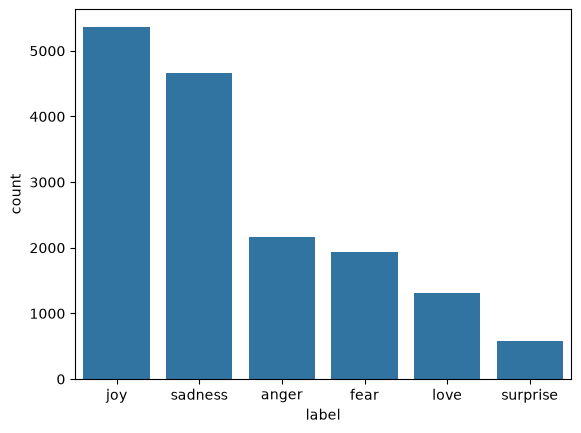

In [18]:
sns.countplot(x="label", data=df_train, order=df_train["label"].value_counts().index)

**What should I learn from this?** The visual confirms a
clearly skewed distribution, with `joy` and `sadness` dominating, and `surprise`
being rare. This is the same conclusion the table gave us, but the chart makes it
immediate. This observation directly motivates using `class_weight` during training
(covered further down).


## 3. Text Preprocessing

### Why Preprocessing Is Necessary

Neural networks are mathematical functions — they operate on numbers (specifically,
tensors of numbers), not on words. A sentence like *"I feel happy"* means nothing to
a network until we turn it into numbers in a consistent, meaningful way. This
section handles that conversion in three steps: **tokenization**, **sequence
conversion**, and **padding**.

### Step 1 — Tokenization: From Words to Integers

**What?** Tokenization builds a vocabulary — a lookup table that assigns a unique
integer ID to every distinct word seen in the training text (up to a limit we
choose).

**Why?** We can't feed the string `"happy"` into a matrix multiplication. But we
*can* feed the number `247` (say, whatever ID `"happy"` gets assigned). Tokenization
is the bridge between human language and the numeric world a neural network lives
in.

**Intuition:** Think of it like a classroom roll call. Instead of calling out full
names, the teacher assigns each student a roll number. From then on, "student 14"
and "Aditi" refer to the same person — it's just a more compact, numeric label.

**Key parameters used here:**

| Parameter | Value | Meaning |
|---|---|---|
| `num_words` | 10,000 | Only the 10,000 *most frequent* words get their own ID; rarer words are treated specially |
| `oov_token` | `"<unk>"` | Any word outside the top 10,000 (Out-Of-Vocabulary) gets mapped to this special "unknown" token instead of being dropped silently |

**What should I think about?** Why limit the vocabulary to 10,000 words instead of
using every unique word? Two reasons: (1) very rare words appear so few times that
the model can't learn anything reliable about them anyway, and (2) a smaller
vocabulary means a smaller (and faster-to-train) embedding layer. The `oov_token`
ensures that when a rare or unseen word does show up, the model still gets *some*
consistent signal ("this is an unknown word") rather than crashing or silently
skipping it.

### Step 2 — Sequence Conversion

Once the tokenizer has learned its vocabulary from the training text
(`fit_on_texts`), `texts_to_sequences` converts every sentence into a list of
integers — one integer per word, in order. For example, *"i feel happy"* might
become `[3, 15, 247]`.

**Important:** the tokenizer is fit **only on `df_train["text"]`**, never on the
test text. It's then *reused* (not re-fit) to convert the test text. This matters —
see the note below.

> **Potential issue:** Because `oov_token="<unk>"` is set, any word in the test set
> that never appeared in training simply becomes `<unk>` rather than causing an
> error. This is expected and correct behavior — just worth understanding, since it
> means the model can never "recognize" a genuinely new word at inference time, only
> treat it as unknown.

### Step 3 — Padding: Making Every Sentence the Same Length

**Why is this necessary?** Neural networks (especially when processing data in
batches) expect inputs of a *fixed* shape. But real sentences have different
lengths — some are 3 words, others are 30. Padding solves this by forcing every
sequence to the same length (`maxlen=50` here):

- Sentences **shorter** than 50 tokens get padded with zeros.
- Sentences **longer** than 50 tokens get truncated (cut off).

**Parameters used:**

| Parameter | Value | Meaning |
|---|---|---|
| `maxlen` | 50 | Every sequence will be exactly 50 tokens long |
| `padding="post"` | — | Zeros are added **after** the real tokens, not before |
| `truncating="post"` | — | If a sentence is too long, tokens are cut off the **end**, not the beginning |

**What should I think about before choosing `maxlen=50`?** Too short, and long
sentences lose information (truncation). Too long, and short sentences are mostly
padding (wasted computation, and the model has to learn to "ignore" a lot of
zeros). A reasonable choice is usually informed by looking at the actual
distribution of sentence lengths — which is exactly what the histogram in the next
cell does.


In [19]:
from tensorflow.keras.preprocessing.text import Tokenizer  # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences  # type: ignore

max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token="<unk>")
tokenizer.fit_on_texts(df_train["text"])

train_sequence = tokenizer.texts_to_sequences(df_train["text"])
test_sequence = tokenizer.texts_to_sequences(df_test["text"])

padded_train_sequence = pad_sequences(
    train_sequence, maxlen=50, padding="post", truncating="post"
)
padded_test_sequence = pad_sequences(
    test_sequence, maxlen=50, padding="post", truncating="post"
)

train_labels = np.array(train_label)
test_labels = np.array(test_label)

num_classes = len(np.unique(train_labels))

print(f"Vocabulary Size: {len(tokenizer.word_index)}" )
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


### Result Interpretation

```text
Vocabulary Size: 15213
Max Sentence Length: 50
```

**What does this tell us?** The training data actually contains **15,213 unique
words**, but we deliberately capped the tokenizer at the 10,000 most frequent ones
(`num_words=10000`). This means roughly 5,000 rarer words will be treated as
`<unk>` rather than getting their own ID — a reasonable trade-off given how rare
those words likely are.

`padded_train_sequence.shape[1]` confirms every sequence is now exactly 50 tokens
long, as configured. From this point on, every model in the notebook receives
input of shape `(batch_size, 50)` — 50 integers per sentence.


### Checking Our `maxlen` Choice

This histogram shows the actual distribution of sentence lengths (in words) across
the training data. It's a useful sanity check *after the fact*: does `maxlen=50`
look like a reasonable choice given how long these sentences actually are?


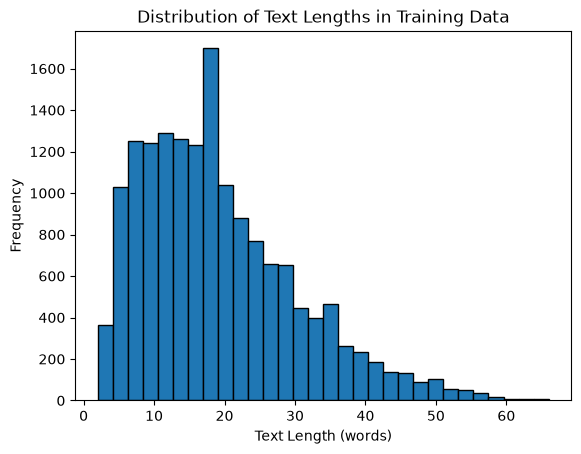

In [20]:
lengths = df_train["text"].apply(lambda x: len(x.split()))
plt.hist(lengths, bins=30, edgecolor='black')
plt.xlabel('Text Length (words)')
plt.ylabel('Frequency')
plt.title('Distribution of Text Lengths in Training Data')
plt.show()

**What should I learn from this?** If most sentences fall well
under 50 words, then `maxlen=50` mostly adds padding rather than truncating
content — meaning little information is lost, at the cost of some wasted
computation on padding tokens. If many sentences were *longer* than 50, we'd want
to reconsider the cutoff since truncation would be losing real information. Compare
the shape of this histogram to the `maxlen=50` cutoff to judge whether it's a good
fit for this dataset.


## 4. Preparing Data for Deep Learning

### Handling Class Imbalance: Class Weights

We saw earlier that `joy` and `sadness` dominate the training data while
`surprise` and `love` are comparatively rare. **Class weights** are one common way
to counteract this without changing the dataset itself.

**How it works:** during training, the loss contributed by each example is
multiplied by a weight based on its class. Rare classes get a **higher** weight
(so mistakes on them "hurt" more), and common classes get a **lower** weight. This
nudges the model to pay proportionally more attention to minority classes instead
of ignoring them in favor of easy majority-class predictions.

`class_weight="balanced"` (from scikit-learn) computes these weights automatically,
inversely proportional to how frequently each class appears.


In [21]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_label
)

In [22]:
class_weight_dict = dict(enumerate(class_weights))
class_weight_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

### Result Interpretation

The printed dictionary maps each label (as an integer) to its computed weight,
e.g. label `5` (`surprise`, the rarest class) gets the **highest** weight
(~4.66), while label `1` (`joy`, the most common class) gets the **lowest**
weight (~0.50). This directly reflects the imbalance we saw in the bar chart —
rarer classes are weighted roughly proportionally higher. This `class_weight_dict`
is passed into every model's `.fit()` call later in the notebook.


### Preventing Overfitting: Early Stopping

**What?** `EarlyStopping` is a training safeguard that watches a chosen metric
(here, `val_loss` — validation loss) during training and automatically stops
training if it stops improving for a set number of epochs (`patience=3`).

**Why do we need this?** Left to train for a fixed number of epochs regardless of
performance, a model can start **overfitting** — getting better and better on the
training data while actually getting *worse* on unseen data. Early stopping is a
way to catch this automatically rather than manually watching every epoch.

**What does each parameter do?**

| Parameter | Value | Meaning |
|---|---|---|
| `monitor` | `'val_loss'` | Watch validation loss as the signal for whether the model is still improving |
| `patience` | `3` | Allow up to 3 epochs without improvement before stopping |
| `restore_best_weights` | `True` | When training stops, roll the model back to the weights from its *best* epoch, not just the last one |

This same `early_stop` callback object is reused across all four models trained
below, which keeps the stopping criteria consistent for a fair comparison.


In [23]:
from tensorflow.keras.callbacks import EarlyStopping # type:ignore

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

A quick environment check — confirming the installed
TensorFlow version and whether a GPU is available for training. This doesn't
affect the model itself, but training speed (and the warning you may see below)
depends heavily on whether a GPU is being used.


In [24]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.21.0
[]


**Result:** TensorFlow 2.21.0, and an **empty list** for GPU
devices — meaning training below runs on CPU. The printed warning explains why:
native Windows doesn't support GPU acceleration for TensorFlow ≥ 2.11 (WSL2 or
DirectML would be needed for that). This is worth keeping in mind when looking at
the training times reported in later cells — they reflect CPU-only training.


## 5. Understanding Neural Networks for Text

### Why Sequence Models?

Text is **sequential data** — word order matters. *"The dog bit the man"* and
*"The man bit the dog"* contain the exact same words, but mean completely
different things. A plain feed-forward neural network has no built-in concept of
order — it would treat a sentence more like a bag of words. To understand meaning,
a model needs some way to process words **in order**, remembering what came
before. That's exactly what **recurrent** architectures (RNN, LSTM, GRU) are
designed for.

### Neural Network Basics (Quick Primer)

Before diving into RNNs, a few core ideas that apply to every model in this
notebook:

- **Layer** — a building block that transforms its input into some output (e.g. an
  `Embedding` layer, a `Dense` layer).
- **Weights & bias** — the numbers a layer learns during training; they start
  random and get adjusted to reduce error.
- **Activation function** — a function applied to a layer's output that lets the
  network model non-linear relationships (here, `softmax` on the final layer — more
  on that below).
- **Forward pass** — feeding input through the network to get a prediction.
- **Loss** — a number measuring how wrong the prediction was.
- **Backpropagation** — the algorithm that uses the loss to figure out how to
  adjust every weight in the network to do better next time.
- **Optimizer** — the specific method used to make those weight adjustments (here,
  `adam`, a widely-used default choice).
- **Epoch** — one full pass through the entire training dataset.
- **Batch** — training data is processed in small chunks (batches), not all at
  once, for memory and stability reasons.

## 6. Model 1 — Simple RNN

### RNN Intuition

**What is an RNN?** A Recurrent Neural Network processes a sequence one element
(word) at a time, and — critically — carries forward a **hidden state**: a
running summary of everything it has seen so far in the sequence.

**Analogy:** imagine reading a sentence word by word, and after each word you
update a short mental note summarizing "what the sentence seems to be about so
far." By the time you reach the last word, that note reflects the whole sentence.
That mental note is the hidden state.

```text
word 1 → [RNN cell] → hidden state 1
word 2 → [RNN cell + hidden state 1] → hidden state 2
word 3 → [RNN cell + hidden state 2] → hidden state 3
   ...
last word → final hidden state (summary of the whole sentence)
```

**Strengths:** conceptually simple, and naturally suited to sequences.

**Limitations:** basic RNNs struggle to remember information from many steps
earlier in long sequences — a problem known as the **vanishing gradient problem**
(explained more in the LSTM section, since that's exactly what LSTM was designed to
fix).

### Architecture Used Here

```text
Embedding(10000 words → 128-dim vectors)
        ↓
SimpleRNN(128 units, returns a sequence)
        ↓
Dropout(0.5)
        ↓
SimpleRNN(64 units, returns final summary)
        ↓
Dropout(0.5)
        ↓
Dense(6 units, softmax) → probability per emotion
```

**What is the Embedding layer doing?** Token IDs (like `247`) are just arbitrary
integers — the number `247` isn't "closer" to `248` in any meaningful sense than it
is to `9000`. An `Embedding` layer learns a **dense vector** (here, 128 numbers) for
every word, such that words used in similar contexts end up with similar vectors.
It's the model's way of learning what words "mean" relative to each other, purely
from how they're used in the training data.

**What is Dropout doing?** `Dropout(0.5)` randomly "turns off" 50% of neurons
during each training step. This forces the network to not over-rely on any single
neuron, which helps prevent overfitting.

**Why `softmax` on the output layer?** We have 6 possible emotions, and want the
model to output a **probability distribution** across all six (that sums to 1),
rather than one arbitrary score. `softmax` takes raw output scores and converts
them into probabilities — the class with the highest probability becomes the
prediction.

**Why `sparse_categorical_crossentropy` as the loss?** This loss function is the
standard choice for multi-class classification when labels are given as plain
integers (`0`–`5`) rather than one-hot encoded vectors — which matches exactly how
`train_labels` and `test_labels` are formatted here.

**What should I think about before training?** With two stacked recurrent layers
and heavy dropout, this is a reasonably deep, regularized RNN. Whether it performs
well is an empirical question — we're about to find out.


In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN , Embedding , Dense , Dropout , LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim=max_words , output_dim=128 , input_length= 50),
    SimpleRNN(units = 128 , return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units = 64),
    Dropout(0.5),
    Dense(units=num_classes , activation='softmax')
])

rnn_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

d:\Study\data science portfolio projects\Emotion Predictor\backend\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [26]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.1571 - loss: 1.9161 - val_accuracy: 0.2075 - val_loss: 1.7757
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.1586 - loss: 1.8036 - val_accuracy: 0.1120 - val_loss: 1.8009
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.1629 - loss: 1.7837 - val_accuracy: 0.1080 - val_loss: 1.7953
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.1719 - loss: 1.7760 - val_accuracy: 0.1165 - val_loss: 1.7981


### Result Interpretation

```text
Epoch 1: accuracy 0.1571, val_accuracy 0.2075
Epoch 2: accuracy 0.1586, val_accuracy 0.1120
Epoch 3: accuracy 0.1629, val_accuracy 0.1080
Epoch 4: accuracy 0.1719, val_accuracy 0.1165
```

**What happened?** Training stopped after only 4 epochs (early stopping
triggered), and accuracy barely moved above **~17%** — only slightly better than
random guessing among 6 classes (which would average ~16.7%). Validation accuracy
is noisy and, if anything, trending downward.

**What does this mean?** The basic `SimpleRNN` essentially **failed to learn**
this task in any meaningful way within the epochs it was allowed to run. This is a
well-known real-world limitation of simple RNNs — they often struggle to learn
useful patterns from raw text this way, especially with strong dropout and no
extra tuning. This result becomes a useful **baseline**: something the LSTM, GRU,
and BiGRU results below can be meaningfully compared against.

**What should I think about?** Rather than a mistake, this is actually valuable
evidence *for* the sequence of experiments this notebook runs — it's precisely the
kind of practical motivation for trying LSTM and GRU next, since both were
designed to address the memory limitations that plain RNNs suffer from.


## 7. Model 2 — LSTM

### Why LSTM? RNN's Long-Term Memory Problem

Simple RNNs have a well-known weakness: as sequences get longer, the influence of
early words on the hidden state fades out almost completely by the time the network
reaches the end of the sentence. During training, this shows up as the
**vanishing gradient problem** — the signal used to update weights for early time
steps becomes vanishingly small, so the network effectively stops learning from
long-range context.

**Analogy:** picture trying to remember the first sentence of a long story while
you're only allowed to keep updating one short mental note — by chapter 10, that
detail from chapter 1 has almost certainly been overwritten.

### LSTM Intuition: Gated Memory

LSTM (Long Short-Term Memory) was introduced specifically to fix this. Instead of
a single hidden state that gets overwritten at every step, LSTM maintains a
separate **cell state** — a kind of conveyor belt that can carry information across
many time steps largely unchanged — plus a set of **gates** that control what
information flows in, out, or gets forgotten.

```text
Previous Cell State + Previous Hidden State + Current Word
        ↓
   Forget Gate  (what should we throw away from memory?)
        ↓
   Input Gate   (what new information should we add?)
        ↓
   Update Cell State
        ↓
   Output Gate  (what should we reveal as this step's hidden state?)
        ↓
   New Hidden State + New Cell State
```

- **Forget gate** — decides what to discard from the cell state.
- **Input gate** — decides what new information to write into the cell state.
- **Output gate** — decides what part of the (updated) cell state to expose as the
  hidden state used for predictions/output at this step.

**Why does this help?** Because the cell state is updated additively (rather than
being completely overwritten each step, like a basic RNN's hidden state), useful
information can survive across many more time steps, largely avoiding the vanishing
gradient problem.

### Architecture Used Here

```text
Embedding(10000 words → 128-dim vectors)
        ↓
LSTM(128 units, returns a sequence)
        ↓
Dropout(0.5)
        ↓
LSTM(64 units, returns final summary)
        ↓
Dropout(0.5)
        ↓
Dense(6 units, softmax)
```

This mirrors the RNN architecture almost exactly (same embedding size, same
dropout, same dense head) — only `SimpleRNN` is swapped for `LSTM`. This is
intentional: keeping everything else identical isolates the effect of the
architecture change itself, which is exactly what we want for a fair comparison.


Model 2 - Standard LSTM

*(The short heading above is the original author's note in the
notebook — kept as-is. The detailed explanation above it covers the full "why" and
"how" of LSTM.)*


**What should I expect?** Given how poorly the plain RNN
performed, this architecture change — swapping in LSTM's gated memory — is the
first real test of whether better long-term memory handling improves emotion
classification on this dataset.


In [27]:
lstm_model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=128, input_length=50),
        LSTM(units=128, return_sequences=True),
        Dropout(0.5),
        LSTM(units=64),
        Dropout(0.5),
        Dense(units=num_classes, activation="softmax"),
    ]
)

lstm_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [28]:
lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 34ms/step - accuracy: 0.1424 - loss: 1.7937 - val_accuracy: 0.0330 - val_loss: 1.8256
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1337 - loss: 1.7938 - val_accuracy: 0.0330 - val_loss: 1.8016
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1279 - loss: 1.7927 - val_accuracy: 0.1775 - val_loss: 1.7916
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1604 - loss: 1.7776 - val_accuracy: 0.1915 - val_loss: 1.7454
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.2161 - loss: 1.6219 - val_accuracy: 0.1345 - val_loss: 1.7025
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.1445 - loss: 1.7848 - val_accuracy: 0.3330 - val_loss: 1.7666
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.1357 - loss: 1.7870 - val_accuracy: 0.0435 - val_loss: 1.7874
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.1112 - loss: 1.7866 - 

### Result Interpretation

```text
Epoch 8 (final, early-stopped): accuracy 0.1112, val_accuracy 0.0435
Test evaluation → LSTM Loss: 1.7025, LSTM Accuracy: 0.1345 (13.45%)
```

**What happened?** Training ran for 8 epochs before early stopping kicked in
(restoring the best-performing weights, from around epoch 4 where `val_accuracy`
briefly reached ~0.19). Even so, final test accuracy landed at only **13.45%** —
actually *lower* than the RNN's ~17%, and only marginally better than random
guessing.

**What does this mean?** Contrary to what the LSTM theory above would suggest,
this particular LSTM did not clearly outperform the simple RNN on this dataset, in
this run. Looking at the epoch-by-epoch numbers, training accuracy itself stayed
low and unstable for most of training (bouncing around 0.13–0.22) before the
"best" epoch (used by `restore_best_weights`) was reached — suggesting the model
struggled to find a good solution within the epochs allowed, rather than that LSTM
is a poor fit for this kind of task in general.

**What should I think about?** This is a good example of why we shouldn't assume a
theoretically more powerful architecture will automatically perform better in
practice — training dynamics, initialization, and how many epochs are allowed
before early stopping all matter. A GRU is tried next; the comparison in
**Section 9** will look at all four results together to draw a fairer conclusion.


## 8. Model 3 — GRU

### Why GRU?

GRU (Gated Recurrent Unit) is a newer, simplified alternative to LSTM. It aims to
solve the same long-term dependency problem, but with fewer gates and no separate
cell state — just a single hidden state, updated through gating.

### How GRU Differs from LSTM

| | LSTM | GRU |
|---|---|---|
| Memory | Separate cell state + hidden state | Single hidden state only |
| Gates | 3 (forget, input, output) | 2 (update, reset) |
| Parameters | More | Fewer (simpler, often faster to train) |

**Update gate** — decides how much of the past hidden state to keep versus how
much to replace with new information (this single gate effectively combines the
roles of LSTM's forget and input gates).

**Reset gate** — decides how much of the past hidden state to "forget" when
computing the new candidate hidden state, allowing the model to drop irrelevant
past context when needed.

**Why might GRU be a good choice?** With fewer parameters than an equivalent LSTM,
GRU is often faster to train and can perform comparably — particularly appealing
on smaller datasets or when compute is limited (relevant here, since we saw
earlier training is running on CPU).

### Architecture Used Here

```text
Embedding(10000 words → 128-dim vectors)
        ↓
GRU(128 units, returns a sequence)
        ↓
Dropout(0.5)
        ↓
GRU(64 units, returns final summary)
        ↓
Dropout(0.5)
        ↓
Dense(6 units, softmax)
```

Again, this exactly mirrors the RNN and LSTM architectures (same embedding size,
same dropout, same dense head) — only the recurrent layer type changes. This keeps
the three-way comparison fair.


In [29]:
gru_model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=128, input_length=50),
        GRU(units=128, return_sequences=True),
        Dropout(0.5),
        GRU(units=64),
        Dropout(0.5),
        Dense(units=num_classes, activation="softmax"),
    ]
)

gru_model.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

In [30]:
gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - accuracy: 0.1576 - loss: 1.7957 - val_accuracy: 0.3470 - val_loss: 1.7586
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.1507 - loss: 1.7954 - val_accuracy: 0.2905 - val_loss: 1.7670
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - accuracy: 0.1564 - loss: 1.7943 - val_accuracy: 0.3430 - val_loss: 1.7799
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.1459 - loss: 1.7934 - val_accuracy: 0.2855 - val_loss: 1.7666
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3470 - loss: 1.7586
GRU Loss: 1.7585896253585815
GRU Accuracy: 0.34700000286102295


### Result Interpretation

```text
Epoch 4 (final, early-stopped): accuracy 0.1459, val_accuracy 0.2855
Test evaluation → GRU Loss: 1.7586, GRU Accuracy: 0.3470 (34.70%)
```

**What happened?** Training stopped early again (after only 4 epochs), but this
time the best-epoch weights restored by `EarlyStopping` correspond to **34.70%**
test accuracy — meaningfully better than both the RNN (~17%) and the LSTM
(13.45%) trained above.

**What does this mean?** In this particular experiment, the plain GRU
outperformed both the simple RNN and the LSTM. This lines up with GRU's reputation
as sometimes training more easily than LSTM on smaller or less-tuned setups, since
it has fewer parameters to learn and a simpler gating mechanism. That said, 34.7%
accuracy on a 6-class problem is still far from strong — there's clearly more
headroom, which motivates the tuning experiment in Section 10.

**What should I think about?** All three models so far were stopped early by the
same `EarlyStopping(patience=3)` callback, watching `val_loss`. It's worth asking
whether these models were simply not given enough time/capacity to reach their
full potential, versus genuinely being a poor match for the task. The GRU
hyperparameter tuning section below (Section 10) directly investigates this by
changing configuration rather than just architecture.


## 9. Model Comparison (So Far) & 10. GRU Hyperparameter Tuning

### Model Comparison — RNN vs LSTM vs GRU

Based on the actual results above:

| Model | Test Accuracy | Test Loss | Notes |
|---|---|---|---|
| Simple RNN | ~17% (train only shown; not separately evaluated on test) | — | Never really learned; near chance level |
| LSTM | 13.45% | 1.7025 | Underperformed even the RNN in this run |
| GRU | 34.70% | 1.7586 | Best of the three basic models |

**Why isn't accuracy alone the full story?** All three models were trained with
identical epochs budget, identical `EarlyStopping` settings, and identical
architecture shape (just different recurrent cell types). Yet none reached strong
performance. This points to something beyond just "which cell type is best" —
possibly the models need more capacity, a richer embedding, or bidirectional
context. That's exactly what's tried next.

> **Note:** The RNN's test-set accuracy/loss were never explicitly computed with
> `.evaluate()` in the original notebook (only train/validation accuracy is
> visible from the fit() logs) — unlike LSTM and GRU, which both call
> `.evaluate()` on the test set afterward. This is flagged again in the Technical
> Review section at the end.

### Why Try a Bidirectional GRU Next?

The three models above are all **unidirectional** — they read a sentence
left-to-right only, so when processing word *N*, they only know about words
*1...N-1*, not what comes after. But meaning often depends on later words too. For
example, in *"I am not happy, I am furious"*, understanding "happy" is being
negated depends on words that come *after* it.

**Bidirectional** wraps a recurrent layer so that it processes the sequence in
**both directions** — forward (start to end) and backward (end to start) — and
combines the results. This gives every position in the sequence access to context
from *both* earlier and later words.

### What Was Actually Changed (GRU Hyperparameter Tuning)

Comparing this model's configuration to the plain GRU trained above:

| Parameter | Plain GRU | This ("BiGRU") Model | Why it might matter |
|---|---|---|---|
| Recurrent wrapper | Unidirectional `GRU` | `Bidirectional(GRU(...))` | Lets the model see context from both directions, not just left-to-right |
| Embedding `output_dim` | 128 | **300** | A larger embedding gives each word more "room" to encode nuanced meaning, at the cost of more parameters to learn |
| GRU units | 128 → 64 (same) | 128 → 64 (same) | Unchanged |
| Dropout | 0.5 (same) | 0.5 (same) | Unchanged |
| Epochs / batch size / optimizer / loss | Same | Same | Unchanged — isolates the effect of the two changes above |

**What hypothesis is being tested?** That giving the model (a) richer word
representations (300-dim embeddings instead of 128) and (b) access to
bidirectional context will meaningfully improve emotion classification compared to
the unidirectional GRU with smaller embeddings tried earlier.

**What trade-offs exist?** A `Bidirectional` wrapper roughly **doubles** the
recurrent computation (it runs two GRUs — one forward, one backward — and
concatenates their outputs), and the larger embedding adds more trainable
parameters. Both changes mean more compute and memory per training step, which is
noticeable in this notebook since training is running on CPU (as we confirmed
earlier). This is a real cost/benefit trade-off, not a free improvement.

**Potential issue:** because *two* things changed at once (bidirectionality *and*
embedding size), if this model performs better, we won't be able to tell from this
experiment alone *which* of the two changes deserves the credit — a more
controlled experiment would change one variable at a time. This is worth keeping
in mind when interpreting the result below.


In [31]:
from tensorflow.keras.layers import Bidirectional # type:ignore
BiGru = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=300, input_length=50),
        Bidirectional(GRU(units=128, return_sequences=True)),
        Dropout(0.5),
        Bidirectional(GRU(units=64)),
        Dropout(0.5),
        Dense(units=num_classes, activation="softmax"),
    ]
)

BiGru.compile(
    optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"]
)

BiGru.summary()

d:\Study\data science portfolio projects\Emotion Predictor\backend\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Reading the Model Summary

**What should I notice?** The printed summary shows every layer's output shape and
parameter count as `?` / `0 (unbuilt)`. This isn't an error — in Keras, a
`Sequential` model doesn't know its exact shapes until it has actually processed
some input at least once (through `.fit()`, `.predict()`, or an explicit
`.build()` call). Since `.summary()` was called here *before* training, the model
hasn't been "built" yet, so shapes and parameter counts aren't resolved. The
architecture itself (the layers and their configuration) is still correct — only
the summary display is incomplete at this point. After training in the next cell,
the model will be fully built.


**What should I expect?** If the hypothesis above is right,
training accuracy/loss curves should look noticeably healthier than the previous
three models — ideally with less epoch-to-epoch noise and higher accuracy from
early on, given the model now has richer input representations and can look in
both directions along the sequence.


In [32]:
BiGru.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
)

Bi_gru_loss, Bi_gru_accuracy = BiGru.evaluate(padded_test_sequence, test_labels)
print(f"Bi_GRU Loss: {Bi_gru_loss}")
print(f"Bi_GRU Accuracy: {Bi_gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step - accuracy: 0.5492 - loss: 1.0701 - val_accuracy: 0.8900 - val_loss: 0.3661
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9199 - loss: 0.2304 - val_accuracy: 0.9120 - val_loss: 0.2389
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9444 - loss: 0.1485 - val_accuracy: 0.9225 - val_loss: 0.2159
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 25s 49ms/step - accuracy: 0.9572 - loss: 0.1119 - val_accuracy: 0.9185 - val_loss: 0.2363
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 24s 48ms/step - accuracy: 0.9747 - loss: 0.0743 - val_accuracy: 0.9280 - val_loss: 0.2408
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.9756 - loss: 0.0671 - val_accuracy: 0.9180 - val_loss: 0.3026
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9225 - loss: 0.2159
Bi_GRU Loss: 0.21589328348636627
Bi_GRU Accuracy: 0.9225000143051147


### Result Interpretation — This Is a Turning Point

```text
Epoch 1: accuracy 0.5492, val_accuracy 0.8900
Epoch 2: accuracy 0.9199, val_accuracy 0.9120
Epoch 3: accuracy 0.9444, val_accuracy 0.9225  ← best val_loss (0.2159)
Epoch 4: accuracy 0.9572, val_accuracy 0.9185
Epoch 5: accuracy 0.9747, val_accuracy 0.9280
Epoch 6: accuracy 0.9756, val_accuracy 0.9180
Test evaluation → Bi_GRU Loss: 0.2159, Bi_GRU Accuracy: 0.9225 (92.25%)
```

**What happened?** This is a dramatic jump compared to every previous model.
Training accuracy climbs from 55% in epoch 1 to over 97% by epoch 6, and — more
importantly — **validation/test accuracy reaches 92.25%**, roughly **2.7× higher**
than the best of the three earlier models (GRU at 34.70%).

**What does this mean?** The combination of bidirectional context and a larger
embedding dimension produced a massive, clear improvement on this task. Since two
variables changed at once (as noted above), we can't cleanly isolate whether
bidirectionality or the larger embedding contributed more — but together, this
configuration is clearly far better suited to this dataset than any of the
unidirectional models tried earlier.

**Overfitting check:** training accuracy (97.6% by the final epoch) is noticeably
higher than validation/test accuracy (92.25%), which is a normal and expected gap
— it indicates *mild* overfitting, not a serious problem. Notice also that
`EarlyStopping` (with `restore_best_weights=True`) rolled the model back to the
weights from **epoch 3** (`val_loss=0.2159`, the lowest logged), rather than
keeping the final epoch's weights — even though training continued for 3 more
epochs before patience ran out. This is exactly the safeguard against overfitting
that early stopping is meant to provide.

**Why did this succeed where the others struggled?** A plausible explanation,
grounded in what actually changed: bidirectional processing lets the model use
context from *both* directions in a sentence (useful for emotion words whose
meaning depends on surrounding context), and the larger 300-dim embedding gives
the model more capacity to represent nuanced word meaning. Together, these two
changes appear to have given the model what it needed to actually learn the
task — something the smaller, unidirectional models struggled to do even with the
same number of training epochs available.


## 9 (continued). Evaluating the Best Model: Confusion Matrix

### What Is a Confusion Matrix?

Accuracy alone tells us *how often* the model is right, but not *what kind* of
mistakes it makes. A confusion matrix breaks this down by showing, for every true
emotion, exactly which emotion the model predicted — including which emotions get
confused with each other.

**How to read it:** rows represent the true label, columns represent the
predicted label. The diagonal (top-left to bottom-right) represents correct
predictions. Anything off the diagonal is a mistake, and its position tells you
which two emotions are being confused.

**Why does this matter here specifically?** Given the class imbalance we saw
earlier (rare classes like `surprise` and `love`), overall accuracy could still
look good even if the model performs poorly on the rare classes specifically. The
confusion matrix (computed here on the **BiGRU model**, our best-performing model)
lets us check that directly.


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


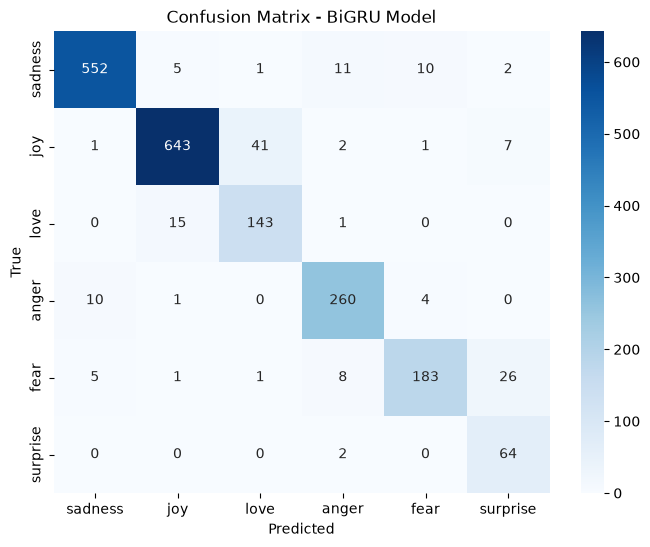

In [34]:
from sklearn.metrics import confusion_matrix

BiGru_predictions = np.argmax(BiGru.predict(padded_test_sequence), axis=1)

cm = confusion_matrix(test_label, BiGru_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_name, yticklabels=label_name)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - BiGRU Model')
plt.show()

**What should I look for?** Strong diagonal values (correct
predictions) relative to off-diagonal values (mistakes) confirm the 92.25%
accuracy is spread reasonably across classes rather than coming entirely from the
majority classes. Any emotion pairs with unusually high off-diagonal values point
to emotions the model finds semantically similar or hard to distinguish (for
example, `fear` and `surprise` can share similar language). Compare this against
the class distribution table from Section 2 — rarer classes like `love` and
`surprise` are the ones most worth double-checking here, since a smaller number of
test examples makes their row/column counts more sensitive to individual mistakes.


## 12. Prediction / Inference on New Text

### The Complete Inference Pipeline

Using a trained model on brand-new text isn't just "call `.predict()`" — the new
text has to go through **exactly the same preprocessing steps** used during
training, or the model will misinterpret it.

```text
New Text
   ↓
Same Tokenizer (already fit on training data — NOT re-fit here)
   ↓
Sequence Conversion (texts_to_sequences)
   ↓
Padding (same maxlen=50, same padding/truncating="post")
   ↓
Trained Model (BiGru) → probability per emotion
   ↓
argmax → most likely class index
   ↓
label_name lookup → human-readable emotion
```

**Why must preprocessing match exactly?** The model was trained on sequences
where, for example, token ID `247` always means the same word, and every input is
padded to length 50 in a specific way. If new text were tokenized differently (say,
with a freshly-created tokenizer, or a different `maxlen`), the same word could map
to a *different* ID than what the model learned during training — the model would
essentially be looking at scrambled, meaningless input. That's exactly why the
**same `tokenizer` object** (already fit on the training data) is reused here
rather than creating a new one.

**What should I expect?** Five example sentences, each clearly written to express
one particular emotion, are run through the pipeline above. Predictions should
mostly match the emotion each sentence was written to express.


In [35]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!",
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(
    sample_sequences, maxlen=50, padding="post", truncating="post"
)

sample_predictions = np.argmax(BiGru.predict(sample_padded_sequences), axis=1)

for i in sample_predictions:
    print(label_name[i])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
surprise
sadness
anger
fear
surprise


### Result Interpretation

| Sentence | Written to express | Model predicted |
|---|---|---|
| "I can't believe how happy I am right now, this is amazing!" | joy | **surprise** |
| "I feel so alone and hopeless today." | sadness | sadness ✓ |
| "I am furious that they cancelled the trip at the last minute." | anger | anger ✓ |
| "I feel terrified when walking down dark alleyways alone." | fear | fear ✓ |
| "I was shocked and completely surprised by the unexpected gift!" | surprise | surprise ✓ |

**What happened?** 4 out of 5 predictions match the intended emotion. The one
mismatch — the first sentence — was predicted as `surprise` rather than `joy`.

**What should we learn from it?** This is a genuinely interesting, plausible
mistake rather than a random one: the sentence contains "I can't believe" and
"amazing," phrasing that overlaps meaningfully with how *surprise* is often
expressed (compare it to the surprise example: "I was shocked and completely
surprised..."). This is a small, real illustration of why the confusion matrix
above matters — individual sentences can genuinely sit at the boundary between two
emotions, and a single example like this doesn't contradict the model's strong
92.25% overall test accuracy, but it does show the kind of mistake the model is
prone to making.


## 13. Model Saving

### Why Save the Trained Model?

Training the BiGRU model above took real time and computation (even more so on
CPU, as we confirmed earlier). We don't want to repeat that process every single
time we want to make a prediction. **Saving** the trained model lets us reload it
later — instantly — for inference, without retraining from scratch.

### What Is Being Saved Here

Two separate files are saved into a folder called `Artifacts`:

1. **`BiGru_Model.h5`** — the trained BiGRU model itself: its architecture *and*
   its learned weights (everything needed to reproduce predictions).
2. **`tokenizer.pkl`** — the fitted `Tokenizer` object, saved using Python's
   `pickle` module.

**Why save the tokenizer too?** This is a detail that's easy to overlook but
critical, and it directly builds on the point made in the inference section above:
new text must go through the *exact same* tokenizer that was used during training,
or word-to-ID mappings won't match what the model learned. Saving `tokenizer.pkl`
alongside the model ensures that whoever loads this model later (e.g., in a
separate API or application) can preprocess new text identically, without needing
access to the original training data.

### Training vs. Inference

This distinction is why saving matters at all:

- **Training** = an expensive, one-time (or occasional) process where the model
  learns from data.
- **Inference** = a cheap, repeated process of using an *already-trained* model to
  make predictions on new data.

Once saved, this model and tokenizer could be loaded into a separate script,
notebook, or web API to serve predictions without ever needing to repeat the
training steps in this notebook.


In [40]:
import os
import pickle

model_dir = "../Artifacts"
os.makedirs(model_dir, exist_ok=True)

BiGru.save(os.path.join(model_dir, "BiGru_Model.h5"))

with open(os.path.join(model_dir, "tokenizer.pkl"), "wb") as file:
    pickle.dump(tokenizer, file)


### What Happened?

The `.save()` call succeeded, but printed a warning: HDF5 (`.h5`) is described as a
**"legacy" format**, with the native Keras format (`.keras`) recommended instead.
The model still saves and will still work — this is a forward-compatibility
warning, not an error. It's flagged again below in the Technical Review section as
a possible improvement.


## 14. Technical Review / Improvements

This section is an honest, evidence-based review of the notebook — based only on
what is actually visible in the code and outputs above. Nothing here changes any
existing code; it's meant as a guide for what to investigate or improve in a next
iteration.

### What Was Done Well

- **Consistent, fair comparison setup**: all four models (RNN, LSTM, GRU, BiGRU)
  share the same preprocessing, the same `EarlyStopping` callback, the same
  `class_weight_dict`, the same optimizer, loss, batch size, and epoch budget. This
  makes the architecture-to-architecture comparison meaningful.
- **Class imbalance was identified and addressed** using computed `class_weight`s,
  rather than being ignored.
- **Missing-value check performed** before proceeding, confirming clean data.
- **Sensible use of `EarlyStopping` with `restore_best_weights=True`**, which
  visibly mattered for the BiGRU model (rolling back to epoch 3's weights).
- **The final model was validated two ways**: a full test-set `.evaluate()` call
  (92.25% accuracy) and a qualitative spot-check on hand-written sample sentences.
- **Both the model and the tokenizer were saved**, correctly recognizing that
  inference requires the same preprocessing object used in training — a step that
  is easy to forget.

### Potential Issues

1. **`validation_data` during training is actually the test set, not the
   `validation` split.** The Hugging Face dataset provides a dedicated 2,000-row
   `validation` split specifically so the `test` split can be held back, untouched,
   for a single final evaluation. In this notebook, `padded_test_sequence` /
   `test_labels` are passed as `validation_data` in every `.fit()` call — meaning
   the "test" set is actually being watched *during* training (for early stopping
   decisions), and then evaluated again afterward as if it were still unseen. The
   loaded `validation` split (from cell 4/5) is never used anywhere. In practice,
   this means the reported test accuracies (e.g., BiGRU's 92.25%) are somewhat
   optimistic — the model's stopping point was chosen based on performance on this
   exact same data, so there's some (likely modest, given the size of the
   improvement) risk of the reported number being slightly inflated versus a truly
   held-out set.

   *Possible improvement: use `emotion_dataset["validation"]` as `validation_data`
   during `.fit()`/early stopping, and reserve `padded_test_sequence` /
   `test_labels` purely for the final `.evaluate()` call after training is
   complete.*

2. **The RNN model's test-set performance was never explicitly measured.** Unlike
   the LSTM, GRU, and BiGRU cells, the RNN cell only calls `.fit()` — there's no
   `.evaluate()` call on the test set. Only training/validation accuracy from the
   fit logs are visible for the RNN, which makes the RNN's row in the comparison
   table slightly less directly comparable to the other three.

   *Possible improvement: add `rnn_model.evaluate(padded_test_sequence,
   test_labels)` for a fully apples-to-apples comparison across all four models.*

3. **Two hyperparameters changed simultaneously in the "tuned" model**
   (bidirectionality *and* embedding dimension, 128 → 300), alongside the
   architecture change from `GRU` to `Bidirectional(GRU(...))`. This makes it
   impossible to attribute the large accuracy jump (34.70% → 92.25%) to a single
   cause with confidence.

   *Possible improvement: as a follow-up experiment, try `Bidirectional(GRU(...))`
   with `output_dim=128` (unchanged embedding) to isolate how much of the gain
   comes from bidirectionality alone, versus a separate run with a
   unidirectional `GRU` at `output_dim=300`.*

4. **No random seed is set** anywhere in the notebook (e.g., no
   `tf.random.set_seed(...)` / `np.random.seed(...)`). This means re-running the
   notebook could produce somewhat different results each time — particularly
   relevant for the RNN and LSTM results, which already showed unstable,
   noisy epoch-to-epoch accuracy, so reproducibility is worth strengthening.

   *Possible improvement: set seeds for `numpy`, `tensorflow`, and Python's
   `random` module near the top of the notebook.*

5. **Model saved in the legacy HDF5 (`.h5`) format**, which Keras explicitly warns
   about, recommending the native `.keras` format instead.

   *Possible improvement: `BiGru.save(os.path.join(model_dir, "BiGru_Model.keras"))`.*

6. **Confusion matrix and sample predictions were computed only for the BiGRU
   model.** This is a reasonable choice since it's the best-performing model, but
   it does mean we can't visually compare *where* the RNN/LSTM/GRU models were
   making mistakes, beyond their overall accuracy numbers.

### Production Considerations

If this model were to move beyond a notebook prototype:

- The **out-of-vocabulary handling** (`<unk>` token) should be tested more
  explicitly with genuinely novel input, since it directly affects real-world
  robustness.
- Precision, recall, and F1-score **per class** (not shown in this notebook, only
  accuracy/loss and the confusion matrix) would give a fuller picture — especially
  important given the class imbalance, since overall accuracy can mask poor
  performance on minority classes like `surprise` and `love`.
- Given the CPU-only training environment identified earlier, moving to a GPU
  environment (or a cloud-hosted one) would likely make iteration on the
  improvements above significantly faster.

---

### Summary

| Model | Test Accuracy | Test Loss |
|---|---|---|
| Simple RNN | Not measured on test set (train acc. ~17%, near chance) | — |
| LSTM | 13.45% | 1.7025 |
| GRU | 34.70% | 1.7586 |
| **Bidirectional GRU** | **92.25%** | **0.2159** |

The Bidirectional GRU — with a larger embedding dimension and bidirectional
context — was clearly the strongest model in this notebook by a wide margin, and
is the one saved for future use.
